# __Compte Rendu du mini projet sur le réchauffement climatique__
### LECLAIR Raphaël 21303231

![image](./AnoTempe.png)

Crédits : NOAA - NASA - UKMet / Traitement ONERC

Depuis le milieu du XIXème siècle, c'est-à-dire depuis la révolution industrielle, on observe une hausse\
des températures moyennes annuelles. On appelle ce phénomène le réchauffement climatique et nous allons essayer\
dans ce mini-projet de montrer que des mesures locales de températures peuvent le mettre en évidence.\
Pour ce faire nous allons utiliser des données de relevés de températures faites chaque jours du\
17 août 1920 au 31 décembre 2019 à la station météorologique de Montélimar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
# Chargement des données
# La première colonne correspond à la date en MJD, la seconde à la température en °C.
data = np.loadtxt("montelimar_temperature.dat")
mjd = data[:, 0]
T = data[:, 1]

In [3]:
# Conversion du MJD en années
# Le MJD est défini par rapport au 17 novembre 1858.
# On convertit ici en années en utilisant l'échelle (365.25 jours par année)
annees = mjd / 365.25 + 1858.0

### Tableaux avec chaque années, température moyenne par année 

In [4]:
Annees=np.floor(annees) #On prends la partie enitère des années.
                        #Dans la conversion les années sont des floats
                        #où la partie flottante représente le mois et le jour
Annees_uniques=np.unique(Annees) #Les années se répètent dans Annees puisqu'il y a eu des mesures tous les jours

In [5]:
print(Annees_uniques)

[1919. 1920. 1921. 1922. 1923. 1924. 1925. 1926. 1927. 1928. 1929. 1930.
 1931. 1932. 1933. 1934. 1935. 1936. 1937. 1938. 1939. 1940. 1941. 1942.
 1943. 1944. 1945. 1946. 1947. 1948. 1949. 1950. 1951. 1952. 1953. 1954.
 1955. 1956. 1957. 1958. 1959. 1960. 1961. 1962. 1963. 1964. 1965. 1966.
 1967. 1968. 1969. 1970. 1971. 1972. 1973. 1974. 1975. 1976. 1977. 1978.
 1979. 1980. 1981. 1982. 1983. 1984. 1985. 1986. 1987. 1988. 1989. 1990.
 1991. 1992. 1993. 1994. 1995. 1996. 1997. 1998. 1999. 2000. 2001. 2002.
 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014.
 2015. 2016. 2017. 2018. 2019.]


In [6]:
Tmoy_A = np.array([T[Annees == a].mean() for a in Annees_uniques[1:-1]]) #On part de 1921 car les mesures commencent en août 1920, ce qui fausse la moyenne

In [7]:
print(f"On trouve une différence de températures moyennes entre 1920 et 2019 de {(Tmoy_A[-1]-Tmoy_A[0]):.3f} degrès Celsius.")

On trouve une différence de températures moyennes entre 1920 et 2019 de 1.066 degrès Celsius.


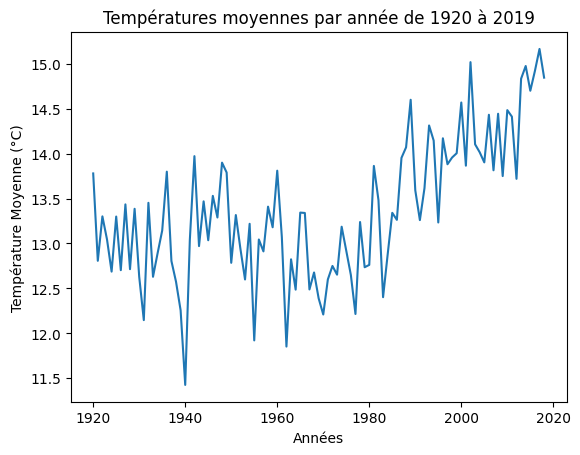

In [8]:
plt.plot(Annees_uniques[1:-1],Tmoy_A)
plt.xlabel("Années")
plt.ylabel("Température Moyenne (°C)")
plt.title("Températures moyennes par année de 1920 à 2019")
plt.show()

On voit bien sur ce graphe qu'il y a une augmentation progressive des températures moyennes annuelles.\
On va maintenant essayer de quantifier cette augmentation, en supposant une erreur de 5°C sur les mesures.

### __Modèle sinusoïdale__

$$ T(t) = A \sin{(\omega t + \phi)} + B $$

où les paramètres $A$ (amplitude), $\phi$ (phase) et $B$ (température moyenne) doivent être ajustés aux données, alors que $\omega = 2\pi/1\text{ an}$.\
On discrétise $t$ jours par jours.

In [9]:
T_1921=T[Annees==1921]
Jours=np.arange(0,365,1)

In [10]:
omega=2*np.pi/365
def Temp(t,A,phi,B):
    return A*np.sin(omega*t+phi)+B

La moyenne des températures en 1921 trouvée par le fit est B=12.807 °C, celle des données est 12.807 °C.


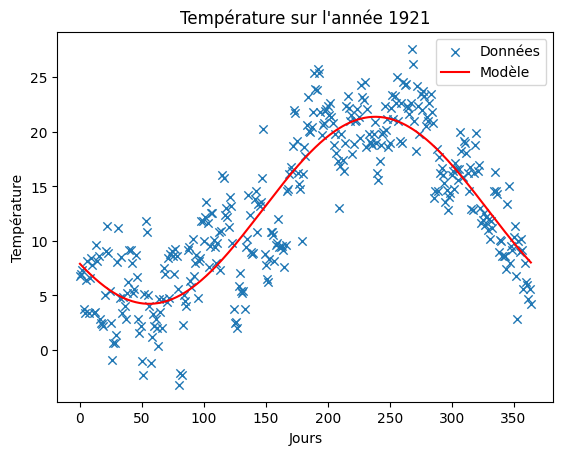

In [11]:
#On regarde le modèle avec l'année 1921

params,pcov=curve_fit(Temp,Jours,T_1921)
A,phi,B=params

print(f"La moyenne des températures en 1921 trouvée par le fit est B={B:.3f} °C, celle des données est {Tmoy_A[1]:.3f} °C.")

plt.scatter(Jours,T_1921,marker="x", linewidth=1, label="Données")
plt.plot(Jours,Temp(Jours,A,phi,B),label="Modèle", color="r")
plt.xlabel("Jours")
plt.ylabel("Température")
plt.title("Température sur l'année 1921")
plt.legend()
plt.show()

Les deux moyennes trouvées sont très proches et le modèle correspond bien aux données.\
Vérifions si c'est toujours le cas sur toutes les années:

In [12]:
# Estimations initiales des paramètres
A0 = (np.max(T) - np.min(T)) / 2  # amplitude approximative
phi0 = 0                          # phase initiale
B0 = np.mean(T)                   # température moyenne

p0 = [A0, phi0, B0]

#On prends le nombre d'années écoulées depuis 1920 pour faciliter le fit
t=annees-np.min(annees)

# On suppose une erreur de mesure de 5 °C pour chaque point
sigma = np.full_like(t, 5.0)

# Ajustement du modèle aux données avec curve_fit
popt, pcov = curve_fit(Temp, t, T, p0=p0, sigma=sigma)
perr = np.sqrt(np.diag(pcov))  # erreurs sur les paramètres

print("Paramètres ajustés :")
print(f"A={popt[0]:.3f} ± {perr[0]:.3f}.")
print(f"phi={popt[1]:.3f} ± {perr[1]:.3f}.")
print(f"B={popt[2]:.3f} ± {perr[2]:.3f}.")

Paramètres ajustés :
A=-3.424 ± 0.343.
phi=1.039 ± 0.040.
B=16.231 ± 0.320.


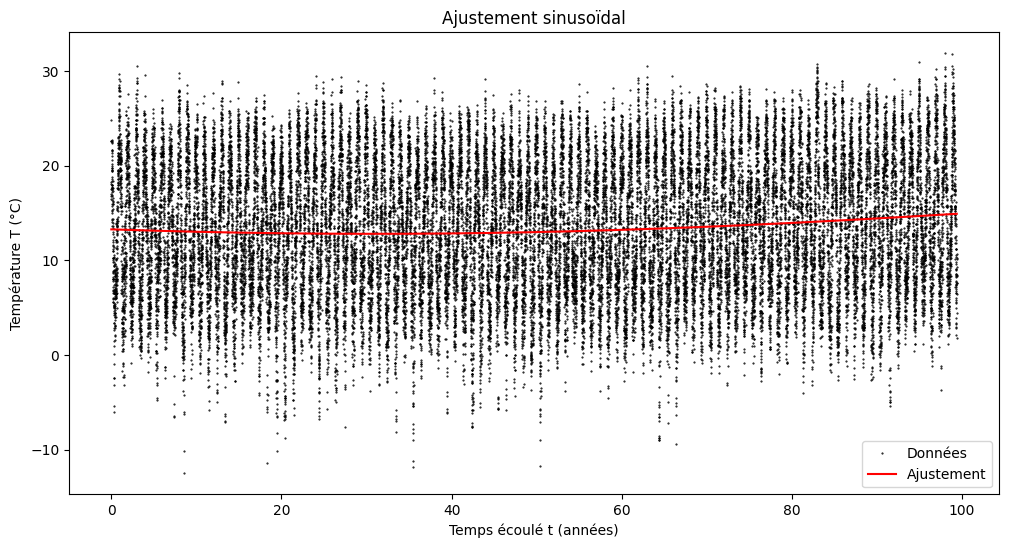

In [13]:
# Affichage
plt.figure(figsize=(12, 6))
plt.plot(t, T, 'k.', markersize=1, label="Données")
plt.plot(t, Temp(t, *popt), 'r-', label="Ajustement")
plt.xlabel("Temps écoulé t (années)")
plt.ylabel("Température T (°C)")
plt.title("Ajustement sinusoïdal")
plt.legend()
plt.show()

On voit bien que le modèle ne marche pas, la moyenne des températures évolue dans le temps\
tandis que $B$ reste constant.

### __Modèle sinusoïdale avec augmentation linéaire__

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où $C$ est un nouveau paramètre à ajuster, qui correspond à l'accroissement linéaire lent de la température.\
Avec ce modèle la moyenne temporelle sur une période $T=\dfrac{2\pi}{\omega}$ augmente.

In [14]:
omega=2*np.pi #on prends seleument 2*pi/1  et pas 2*pi/365 car on va discrétiser le temps en années cette fois
def Temp(t,A,phi,B,C):
    return A*np.sin(omega*t+phi)+B+C*t

In [15]:
# Estimations initiales des paramètres
A0 = (np.max(T) - np.min(T)) / 2  # amplitude approximative
phi0 = 0                          # phase initiale
B0 = np.mean(T)                   # température moyenne
C0 = 0.01                         # tendance linéaire initiale (en °C par an)

p0 = [A0, phi0, B0, C0]

#On prends le nombre d'années écoulées depuis 1920 pour faciliter le fit
t=annees-np.min(annees)

# On suppose une erreur de mesure de 5 °C pour chaque point
sigma = np.full_like(t, 5.0)

# Ajustement du modèle aux données avec curve_fit
popt, pcov = curve_fit(Temp, t, T, p0=p0, sigma=sigma)
perr = np.sqrt(np.diag(pcov))  # erreurs sur les paramètres

print("Paramètres ajustés :")
print(f"A={popt[0]:.3f} ± {perr[0]:.3f}.")
print(f"phi={popt[1]:.3f} ± {perr[1]:.3f}.")
print(f"B={popt[2]:.3f} ± {perr[2]:.3f}.")
print(f"C={popt[3]:.3f} ± {perr[3]:.3f}.")

Paramètres ajustés :
A=-9.009 ± 0.024.
phi=-1.105 ± 0.003.
B=12.530 ± 0.033.
C=0.017 ± 0.001.


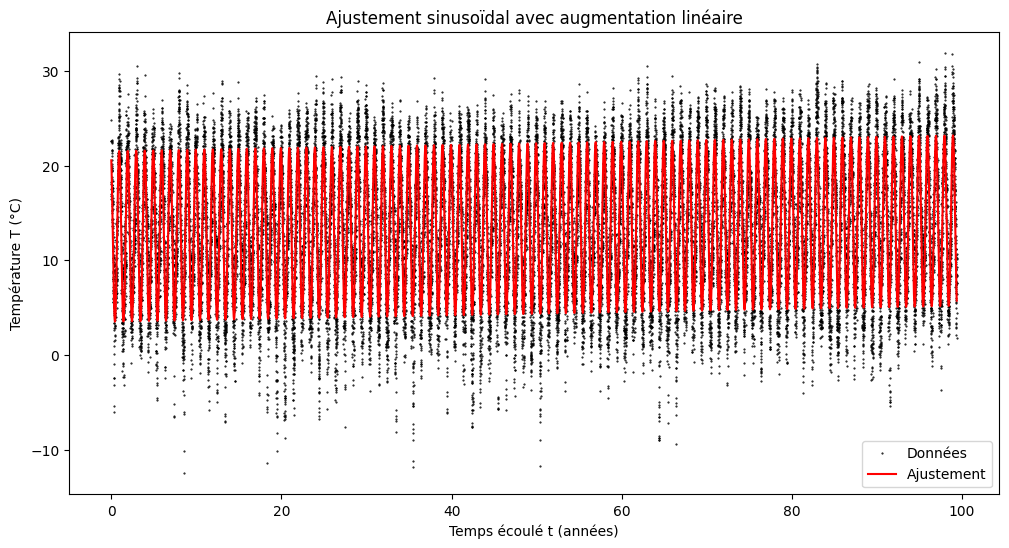

In [16]:
# Affichage
plt.figure(figsize=(12, 6))
plt.plot(t, T, 'k.', markersize=1, label="Données")
plt.plot(t, Temp(t, *popt), 'r-', label="Ajustement")
plt.xlabel("Temps écoulé t (années)")
plt.ylabel("Température T (°C)")
plt.title("Ajustement sinusoïdal avec augmentation linéaire")
plt.legend()
plt.show()

## __Conclusion__

On voit que le modèle ajusté correspond parfaitement aux données et que l'erreur sur l'augmentation progressive\
des températures et bien inférieure à celle sur les mseures.\
Couplés au fait qu'on obtient un facteur d'acroissement assez lent comme observé on peut en conclure que\
ce modèle marche.\
On a ainsi montré que des mesures effectuées localement mettent en évidence une réchauffement significatif. 